## IO

## 并发编程

## 网络编程

### TCP包头

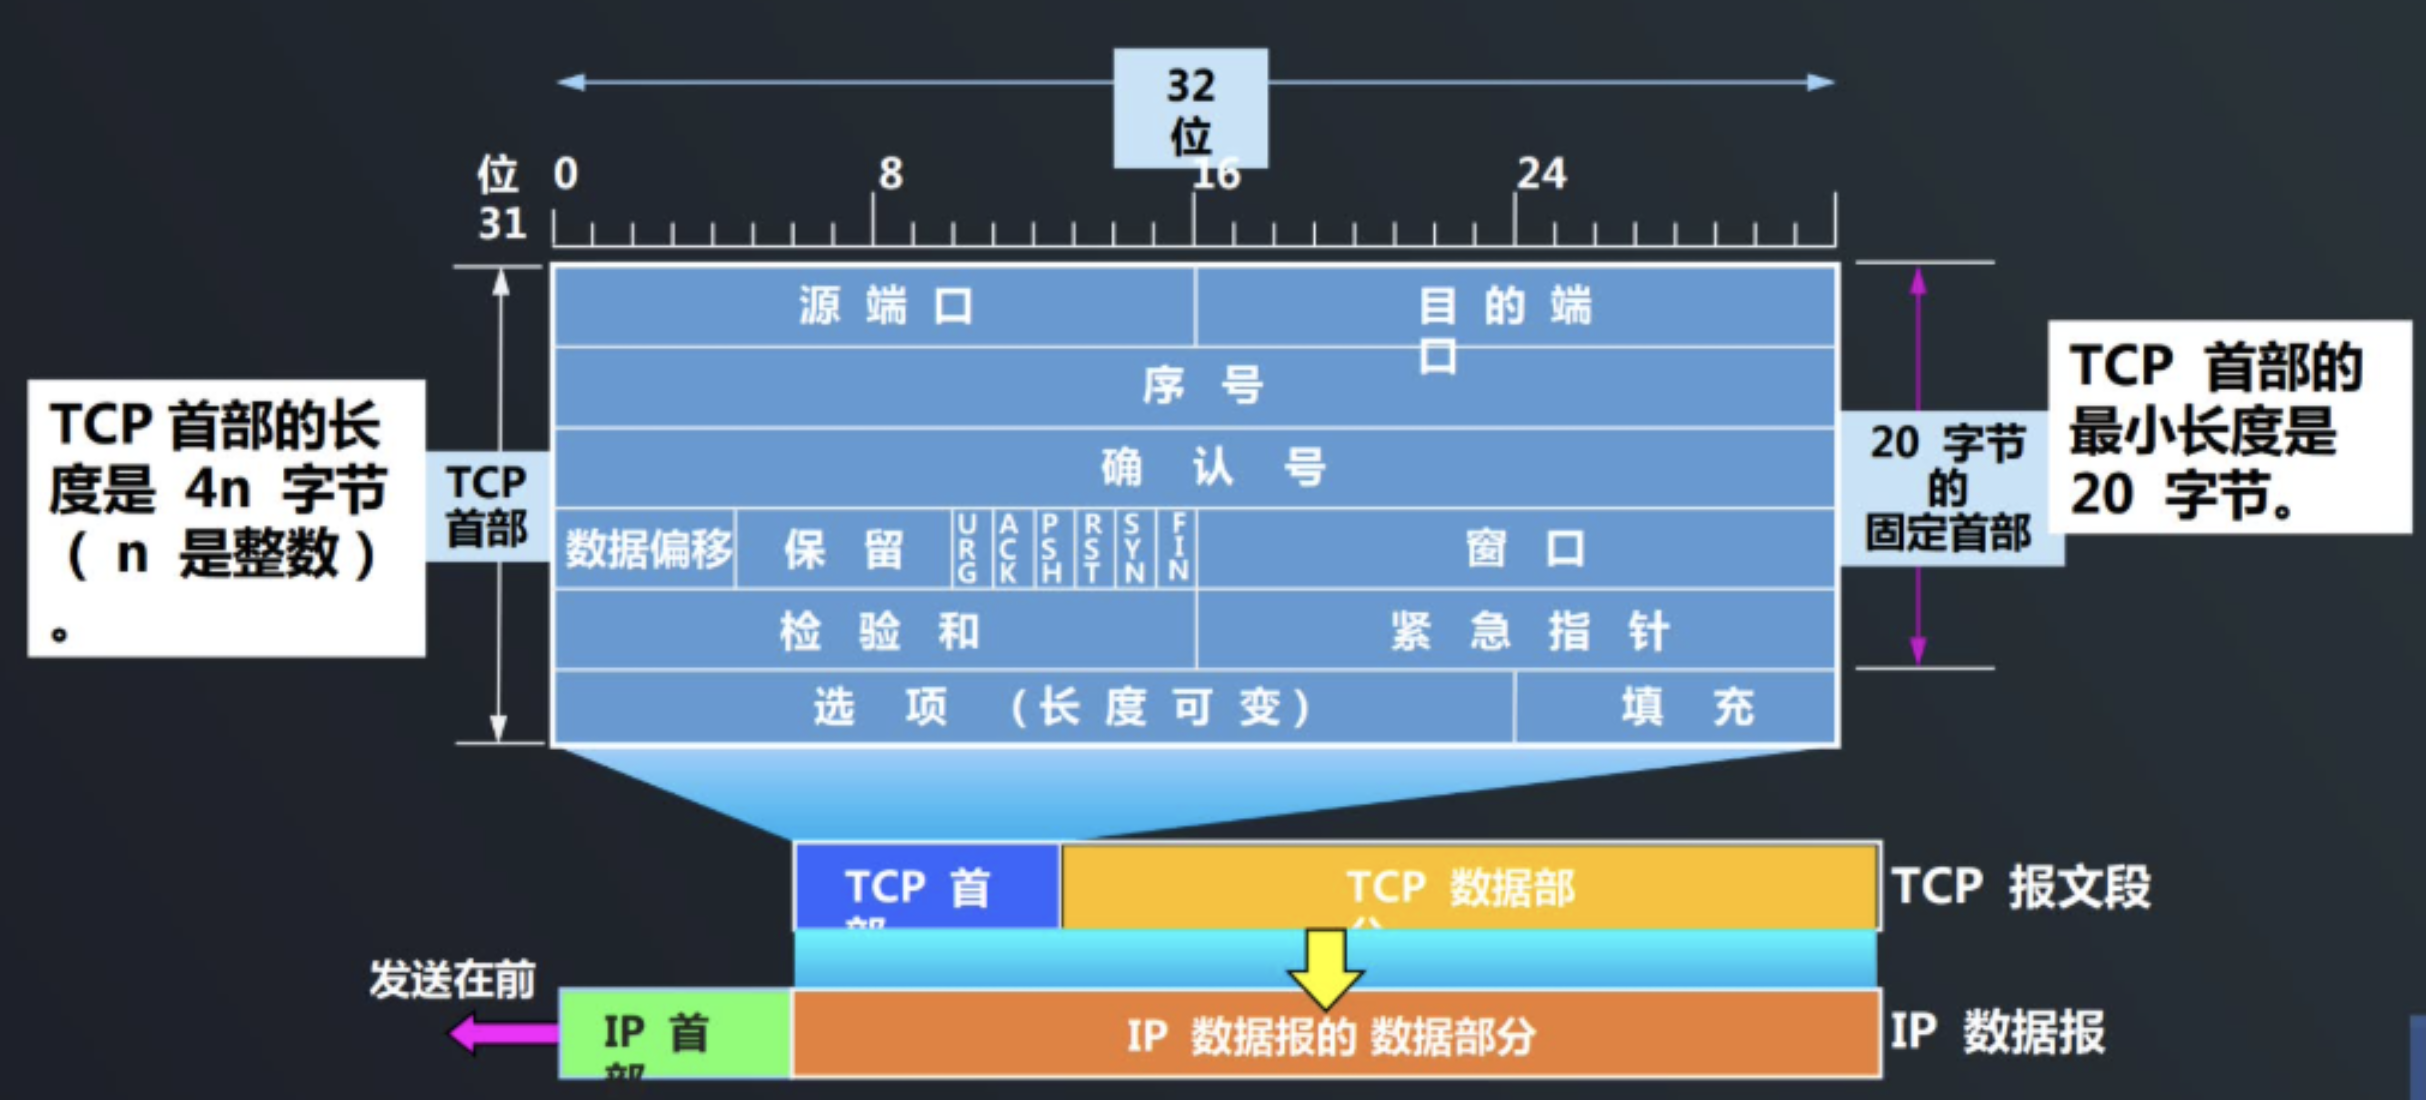

### TCP三握手四挥手

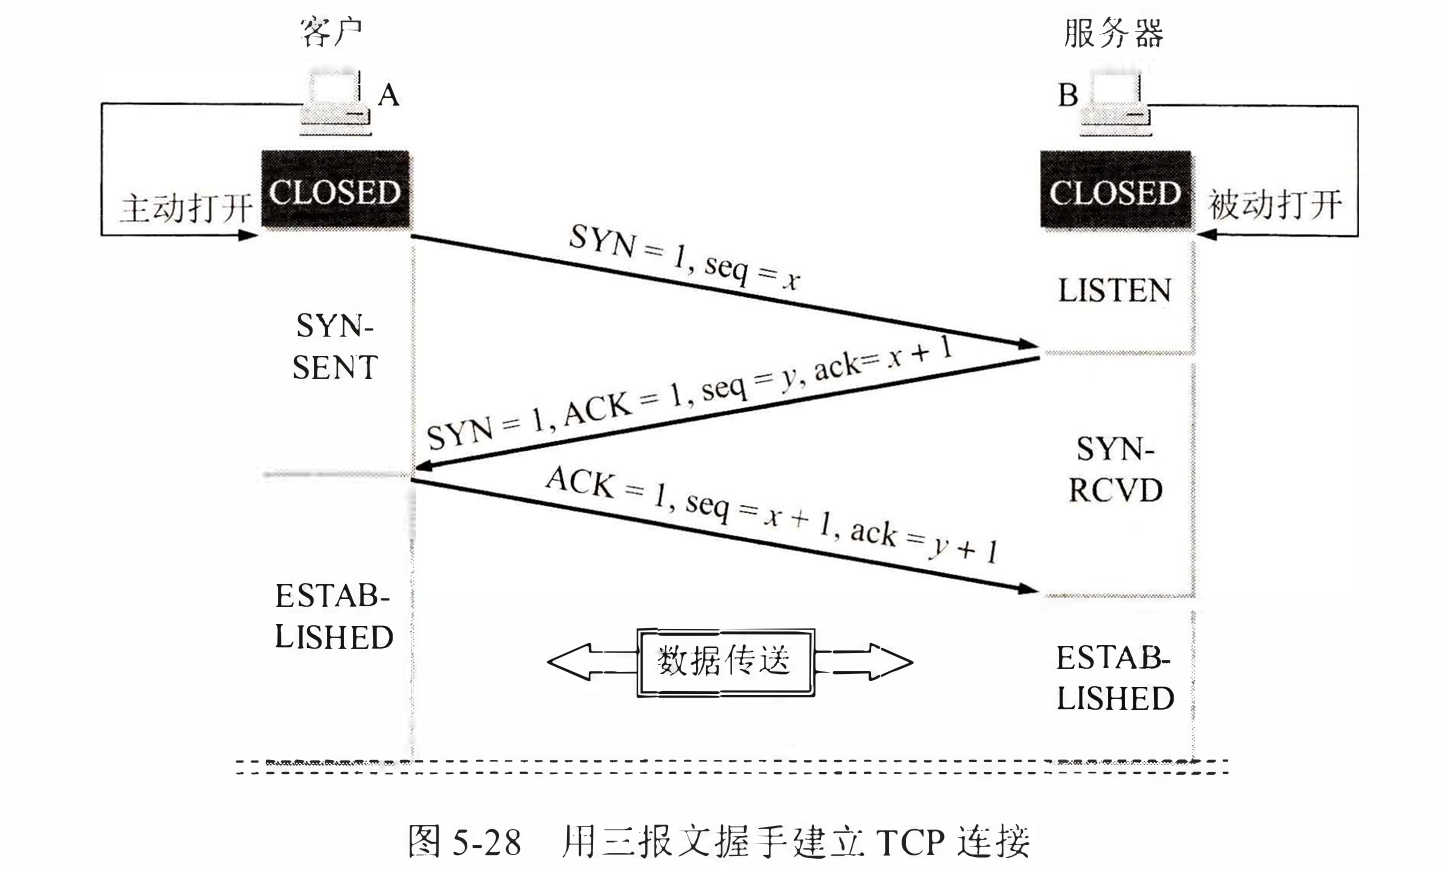

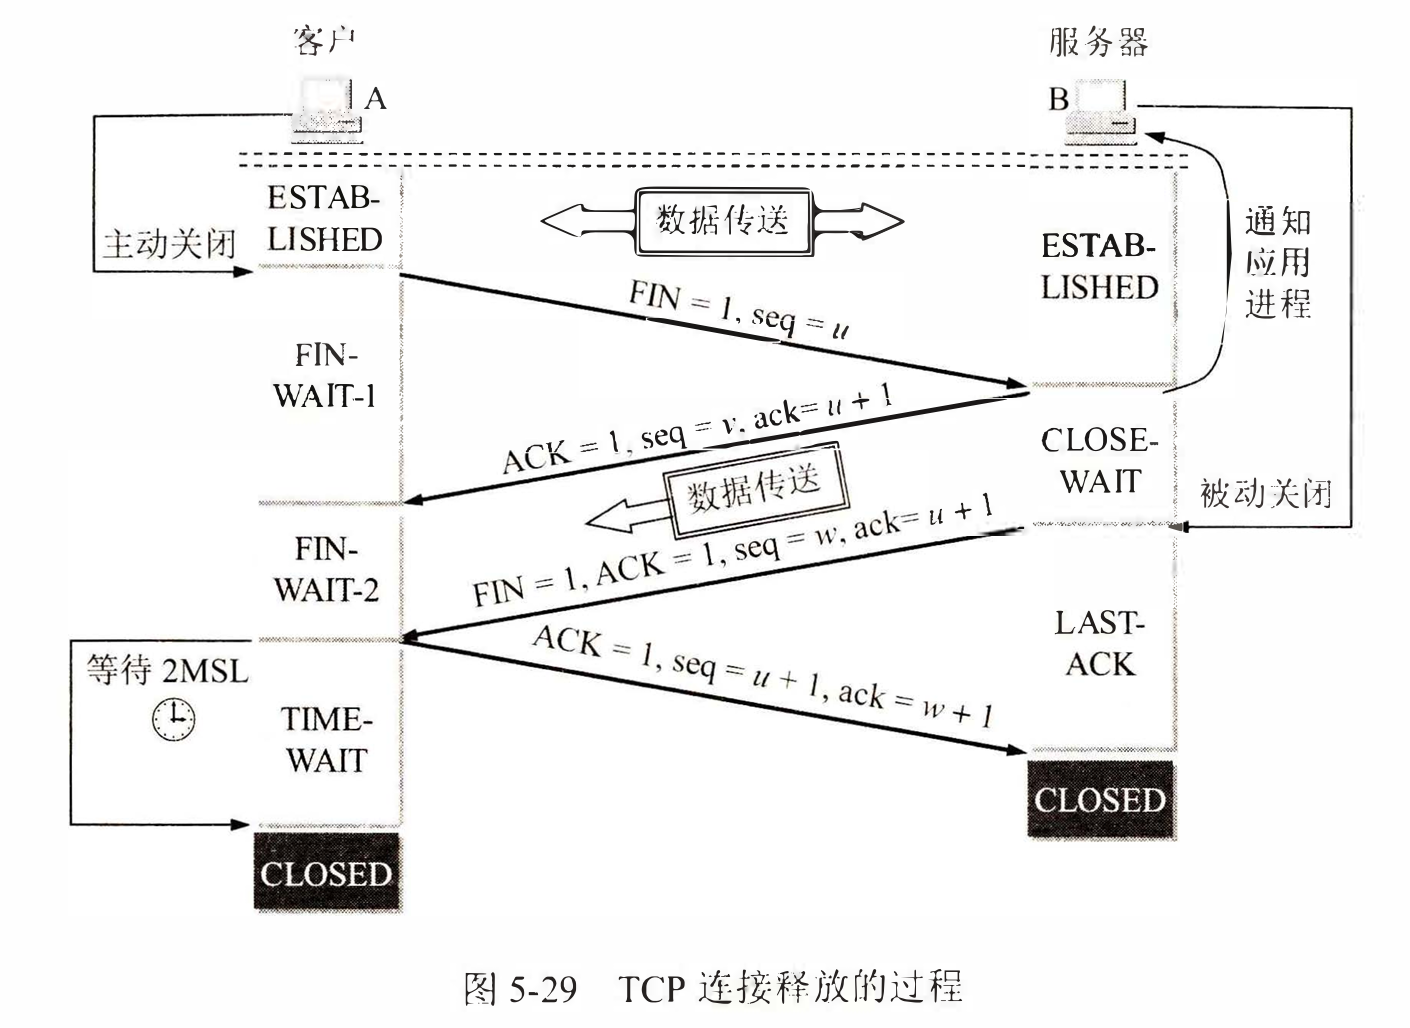

In [ ]:
三握手(建立连接)
-------------------------------------------------------
客户端                              服务端
  |                                  |
  |        SYN=1, seq=x              |
  |--------------------------------->|
  |                                  |
  |    SYN=1, ACK=1, seq=y, ack=x+1  |
  |<---------------------------------|
  |                                  |
  |        ACK=1, seq=x+1, ack=y+1   |
  |--------------------------------->|
  |                                  |
第一次：客户端 → 服务端，证明客户端的发送能力正常
第二次：服务端 → 客户端，证明服务端的接收和发送能力正常
第三次：客户端 → 服务端，证明客户端的接收能力正常
-------------------------------------------------------


四挥手(断开连接，正常结束进程)
-------------------------------------------------------
客户端                              服务端
  |                                  |
  |        FIN=1, seq=u              |
  |--------------------------------->| (客户端主动关闭)
  |                                  |
  |        ACK=1, seq=v, ack=u+1     |
  |<---------------------------------| (服务端确认)
  |                                  | (可能还有数据要发送)
  |        FIN=1, ACK=1, seq=w, ack=u+1|
  |<---------------------------------| (服务端发送FIN)
  |                                  |
  |        ACK=1, seq=u+1, ack=w+1   |
  |--------------------------------->| (客户端确认，等待2MSL后关闭) -> 最后一次挥手传到服务器 + 服务器若再次确认发FIN包 = 2MSL
  |                                  |                      (MSL = Maximum Segment Lifetime，最大报文段生存时间(固定)) 
                                                            (RTT = Round Trip Time，往返时间, 一个报文从发出到收到响应的往返时间(受路径、排队、拥塞、重传、负载变化影响)) 
第一次：客户端发送FIN，表示没有数据要发送了
第二次：服务端确认收到FIN，但可能还有数据要发送
第三次：服务端发送FIN，表示服务端也没有数据要发送了
第四次：客户端确认收到服务端的FIN
-------------------------------------------------------

会话创立过程遵从：服务端开启->客户端开启->客户端关闭->服务端关闭
    若先关服务端进入TIME_WAIT状态，相同地址再用服务端bind会显示占用。（等待TIME_WAIT结束/设置SO_REUSEADDR）
